In [30]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import pandas as pd




Se usara y ver la base de datos principales 

In [31]:
# La base de datos de la encuesta de la vendimia, son los datos de los encuestados de algunos visitantes de la vendimia
# que fue realizada por la municipalidad y ese encuentra  vienen en un excel en diferentes hojas, entonces se guardo la hoja que se va a usar en .csv.
# que quedo y se llamo poblacionporedad.
# link de acceso: https://drive.google.com/file/d/1VGLZvZ4OsOEGJc1RinLuy8iJz2aOMo-s/view

file_id_encuesta = "1VGLZvZ4OsOEGJc1RinLuy8iJz2aOMo-s"

url = f"https://drive.google.com/uc?id={file_id_encuesta}"

vendimia = pd.read_csv(
    url,
    sep=";",
    engine="python"
)

#Se va a ver como es la tabla con los 20 primeras filas
vendimia.head(20)


,Marca temporal,¿Cuál es su edad?,¿Con qué género se identifica usted?,¿En qué comuna reside actualmente?,Alojamiento y estadía,Responda esta pregunta solo si en la anterior seleccionó “Sí”.,¿Qué tipo de alojamiento utilizó?,Transporte: $,Alojamiento: $,Alimentación: $,"Compras (vino, recuerdos, artesanías): $",Seguridad,Limpieza,Comodidad,Programación artística,Acceso a baños,"¿Estás de acuerdo con la afirmación: ""La Vendimia refuerza la identidad cultural de San Fernando""?"
0,05-02-2025 18:50,58,NaN,San Fernando,No,0,Casa propia,0,0,5000,5000,5,5,5,1,5,5
1,05-02-2025 18:55,16,NaN,San Fernando,No,0,Casa,0,0,5000,9000,4,4,4,5,5,4
2,05-02-2025 19:02,63,NaN,Coquimbo,Sí,3,Casa de amigos o familiares,100000,0,0,100000,5,5,5,5,5,5
3,05-02-2025 19:04,23,NaN,Coltauco,No,0,Vienen por el dia,8000,0,60000,50000,5,5,5,1,3,4
4,05-02-2025 19:06,46,NaN,La cruz,No,0,Viaje,100000,0,50000,50000,5,5,5,3,5,5
5,05-02-2025 19:07,13,NaN,Coltauco,No,0,Vienen por el dia,10000,0,60000,30000,5,5,5,3,3,3
6,05-02-2025 19:08,39,NaN,Mostazal,No,0,Viajando,50000,0,50000,50000,5,5,5,3,5,5
7,05-02-2025 19:09,37,NaN,San Fernando,No,0,Casa propia,30000,0,10000,0,5,5,5,5,5,5
8,05-02-2025 19:11,35,NaN,Metropolitana,No,0,Viaje,Viaje,0,40000,15000,5,5,5,3,2,5
9,05-02-2025 19:13,46,NaN,Metropolitana,No,0,Viaje,15000,0,45000,15000,5,5,5,3,2,5


In [32]:
#Saber cuáles son las columnas
print (vendimia.columns.tolist())

['Marca temporal', '  ¿Cuál es su edad?  ', '¿Con qué género se identifica usted?  ', '  ¿En qué comuna reside actualmente?  ', '  Alojamiento y estadía  ', 'Responda esta pregunta solo si en la anterior seleccionó “Sí”.  ', '¿Qué tipo de alojamiento utilizó?  ', 'Transporte: $  ', 'Alojamiento: $  ', 'Alimentación: $  ', 'Compras (vino, recuerdos, artesanías): $  ', 'Seguridad ', 'Limpieza  ', 'Comodidad  ', 'Programación artística  ', 'Acceso a baños  ', '¿Estás de acuerdo con la afirmación: "La Vendimia refuerza la identidad cultural de San Fernando"? ']


In [33]:
#Se tiene que saber cuantas filas y columnas hay, la primera es para saber si estan todos los datos
vendimia.shape

(390, 17)

In [34]:
#Para saber la informacion de la tabla, cual es su formato, si tiene datos nulos, entre otros.
vendimia.info()

<class 'pandas.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 17 columns):
 #   Column                                                                                               Non-Null Count  Dtype  
---  ------                                                                                               --------------  -----  
 0   Marca temporal                                                                                       390 non-null    str    
 1     ¿Cuál es su edad?                                                                                  390 non-null    int64  
 2   ¿Con qué género se identifica usted?                                                                 0 non-null      float64
 3     ¿En qué comuna reside actualmente?                                                                 390 non-null    str    
 4     Alojamiento y estadía                                                                              390 non-null    str 

Del info, estas son textos:
- En qué comuna reside actualmente?: esta bien que sea texto, hay que arreglar los textos. 
- Alojamiento y estadía: pregunta de si y no, esta bien que sea texto
- Responda esta pregunta solo si en la anterior seleccionó “Sí”: Es dias, tiene que ser numero.
- ¿Qué tipo de alojamiento utilizó?: Texto, o agrupar 
- Transporte: Son valores, entonces esto indica que hay palabras 

In [35]:
#Primero hay que eliminar los espacios que sobran de los nombres de la columna
vendimia.columns = vendimia.columns.str.strip()
vendimia.columns.tolist()

['Marca temporal',
 '¿Cuál es su edad?',
 '¿Con qué género se identifica usted?',
 '¿En qué comuna reside actualmente?',
 'Alojamiento y estadía',
 'Responda esta pregunta solo si en la anterior seleccionó “Sí”.',
 '¿Qué tipo de alojamiento utilizó?',
 'Transporte: $',
 'Alojamiento: $',
 'Alimentación: $',
 'Compras (vino, recuerdos, artesanías): $',
 'Seguridad',
 'Limpieza',
 'Comodidad',
 'Programación artística',
 'Acceso a baños',
 '¿Estás de acuerdo con la afirmación: "La Vendimia refuerza la identidad cultural de San Fernando"?']

In [36]:
#Como se ven las ultimas 10 filas
vendimia.tail(10)

,Marca temporal,¿Cuál es su edad?,¿Con qué género se identifica usted?,¿En qué comuna reside actualmente?,Alojamiento y estadía,Responda esta pregunta solo si en la anterior seleccionó “Sí”.,¿Qué tipo de alojamiento utilizó?,Transporte: $,Alojamiento: $,Alimentación: $,"Compras (vino, recuerdos, artesanías): $",Seguridad,Limpieza,Comodidad,Programación artística,Acceso a baños,"¿Estás de acuerdo con la afirmación: ""La Vendimia refuerza la identidad cultural de San Fernando""?"
380,05-04-2025 18:57,50,NaN,San Fernando,No,0,Casa de amigos o familiares,10000,0,30000,45000,5,5,5,3,3,5
381,05-04-2025 18:58,43,NaN,San Fernando,Sí,"2,77",Casa de amigos o familiares,2200,0,45000,35000,5,5,4,3,1,5
382,05-04-2025 18:59,19,NaN,San Fernando,No,0,Casa de amigos o familiares,3000,0,6000,5000,5,5,4,4,4,4
383,05-04-2025 19:00,56,NaN,Santa Cruz,Sí,"2,77",Casa de amigos o familiares,5000,0,56000,95000,5,3,5,5,1,5
384,05-04-2025 19:02,70,NaN,San Fernando,No,0,Casa de amigos o familiares,0,0,5000,0,5,5,5,4,3,5
385,05-04-2025 19:02,62,NaN,San Fernando,No,0,Casa de amigos o familiares,5000,0,25000,0,5,4,5,4,4,4
386,05-04-2025 19:03,30,NaN,San Fernando,No,0,Casa de amigos o familiares,0,0,2000,10000,5,5,4,3,3,5
387,05-04-2025 19:09,37,NaN,San Fernando,No,0,Casa de amigos o familiares,0,0,20000,15000,5,4,4,1,1,5
388,05-04-2025 19:11,27,NaN,San Fernando,No,0,Casa de amigos o familiares,5000,0,10000,0,5,4,4,3,3,5
389,05-04-2025 19:12,30,NaN,San Fernando,No,0,Casa de amigos o familiares,0,0,20000,0,5,5,3,3,5,5


In [37]:
#Saber cuantos datos hay nulos
vendimia.isnull().sum()


Marca temporal                                                                                          0
¿Cuál es su edad?                                                                                       0
¿Con qué género se identifica usted?                                                                  390
¿En qué comuna reside actualmente?                                                                      0
Alojamiento y estadía                                                                                   0
Responda esta pregunta solo si en la anterior seleccionó “Sí”.                                          0
¿Qué tipo de alojamiento utilizó?                                                                       0
Transporte: $                                                                                           0
Alojamiento: $                                                                                          0
Alimentación: $                               

In [38]:
# La columna de genero tiene 390 nulos, significa que nadie respondio, entonces se elimina
vendimia = vendimia.drop(columns=["¿Con qué género se identifica usted?"])


In [39]:
# Ver si hay duplicados en la tabla
vendimia.duplicated().sum()

np.int64(0)

In [40]:
#Revisar codigos especiale ssi se encuentran.
(vendimia == 999).sum().sum()

(vendimia == -1).sum().sum()

np.int64(0)

In [41]:
#Se realiza un describe para ver si hay datos raros.  
vendimia.describe()

,¿Cuál es su edad?,Alojamiento: $,Alimentación: $,"Compras (vino, recuerdos, artesanías): $",Seguridad,Limpieza,Comodidad,Programación artística,Acceso a baños,"¿Estás de acuerdo con la afirmación: ""La Vendimia refuerza la identidad cultural de San Fernando""?"
count,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000
mean,38.812821,4197.435897,25587.179487,22720.512821,4.800000,4.743590,4.512821,3.502564,3.407692,4.884615
std,14.136621,36417.523023,26408.912956,23601.475701,0.574523,0.642054,0.865559,1.321658,1.485298,0.526441
min,13.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,27.000000,0.000000,10000.000000,10000.000000,5.000000,5.000000,4.000000,3.000000,2.000000,5.000000
50%,38.000000,0.000000,20000.000000,20000.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000
75%,49.000000,0.000000,30000.000000,30000.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,78.000000,500000.000000,220000.000000,250000.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


Con el describe, nos damos cuenta que los valores de evaluacion esta en los valores minimos y maximos correctos, que son 0 y 5, respectivamente. Y a su vez se observa que la edad de los asistentes fueron entre 13 y 78 años. 

In [42]:
#Ahora se limpia la columna de comunas donde reside
vendimia["¿En qué comuna reside actualmente?"].value_counts()

¿En qué comuna reside actualmente?
San Fernando        267
Santiago             17
Rancagua             11
Chimbarongo          10
Santa Cruz            8
Chimbarongo           5
Santiago              4
Rengo                 4
La Florida            4
Placilla              3
Nancagua              3
Metropolitana         2
Tinguiririca          2
Las condes            2
Talca                 2
San vicente           2
Curico                2
Providencia           2
Coquimbo              1
Coltauco              1
La cruz               1
Coltauco              1
Mostazal              1
Antofagasta           1
Santa Cruz            1
Lo barnechea          1
Pinto                 1
Marchigue             1
La Florida            1
San Bernardo          1
Maipu                 1
Estación central      1
Peñaloren             1
Doñihue               1
Talgante              1
Machali               1
Pichilemu             1
Limache               1
San juaquin           1
Graneros              1
Grane

In [43]:
#Eliminar los espacion de las comunas donde recide actualmente 
vendimia["¿En qué comuna reside actualmente?"] = (vendimia["¿En qué comuna reside actualmente?"]
.str.strip()
.str.title())

In [44]:
#Ver como la cuenta de la comuna que quedo despues de la eliminacion
vendimia["¿En qué comuna reside actualmente?"].value_counts()

¿En qué comuna reside actualmente?
San Fernando        267
Santiago             21
Chimbarongo          15
Rancagua             12
Santa Cruz            9
La Florida            6
Nancagua              4
Rengo                 4
Placilla              3
San Vicente           3
Coltauco              2
Metropolitana         2
Tinguiririca          2
Las Condes            2
Talca                 2
Curico                2
Providencia           2
Graneros              2
Coquimbo              1
La Cruz               1
Mostazal              1
Antofagasta           1
Lo Barnechea          1
Pinto                 1
Marchigue             1
San Bernardo          1
Maipu                 1
Estación Central      1
Peñaloren             1
Doñihue               1
Talgante              1
Machali               1
Pichilemu             1
Limache               1
San Juaquin           1
San Miguel            1
Puente Alto           1
Puente Varas          1
Quilicura             1
Talagante             1
Renca

In [45]:
#Metropolitana es la region, entonces se va a colocar la ciudad Santiago 
vendimia["¿En qué comuna reside actualmente?"] = (vendimia["¿En qué comuna reside actualmente?"].replace("Metropolitana", "Santiago"))

In [46]:
vendimia["¿En qué comuna reside actualmente?"].value_counts()

¿En qué comuna reside actualmente?
San Fernando        267
Santiago             23
Chimbarongo          15
Rancagua             12
Santa Cruz            9
La Florida            6
Nancagua              4
Rengo                 4
Placilla              3
San Vicente           3
Coltauco              2
Tinguiririca          2
Las Condes            2
Talca                 2
Curico                2
Providencia           2
Graneros              2
Coquimbo              1
La Cruz               1
Mostazal              1
Antofagasta           1
Lo Barnechea          1
Pinto                 1
Marchigue             1
San Bernardo          1
Maipu                 1
Estación Central      1
Peñaloren             1
Doñihue               1
Talgante              1
Machali               1
Pichilemu             1
Limache               1
San Juaquin           1
San Miguel            1
Puente Alto           1
Puente Varas          1
Quilicura             1
Talagante             1
Renca                 1
Romer

In [47]:
#Como era un dato de texto y ver los datos
vendimia["Alojamiento y estadía"].value_counts()

Alojamiento y estadía
No    353
Sí     37
Name: count, dtype: int64

In [48]:
#Se cambio el nombre de la columna "Responda esta pregunta solo si en la anterior seleccionó “Sí”." a Dias_alojamiento para
#que se entienda lo que es.
vendimia = vendimia.rename(columns={"Responda esta pregunta solo si en la anterior seleccionó “Sí”.":
'Dias_Alojamiento'})
vendimia["Dias_Alojamiento"].value_counts()

Dias_Alojamiento
0       353
3        10
2         8
1         7
2,77      6
7         2
4         2
6         1
5         1
Name: count, dtype: int64

El 2,77 es el promedio, que ya venia de esta manera los datos, y son los que si se alojaron, y no pusieron un valor. 

In [49]:
#Como se ve en la info, los datos de alojamiento son texto, y por eso lo cambiaremos a numero
vendimia["Dias_Alojamiento"] = (vendimia["Dias_Alojamiento"].astype(str).str.replace(",", ".", regex=False))
vendimia["Dias_Alojamiento"] = pd.to_numeric(vendimia["Dias_Alojamiento"], errors="coerce")

vendimia["Dias_Alojamiento"].dtype

dtype('float64')

In [50]:
#Como se ve la info, ¿Qué tipo de alojamiento utilizó?" son textos, primero se cambio el nombre para trabajar
#de mejor manera a 'Tipo_Alojamiento', y agruparlas las que significan lo mismo y se escriben distintos.
vendimia = vendimia.rename(columns={"¿Qué tipo de alojamiento utilizó?":
'Tipo_Alojamiento'})
vendimia["Tipo_Alojamiento"].value_counts()



Tipo_Alojamiento
Casa de amigos o familiares    248
Casa propia                     69
Viaje                           36
Viaje                           11
Cabaña/Airbnb                    5
Viene por el dia                 4
Casa propia                      3
Hotel/Hostal                     3
Vienen por el dia                2
Viene por el día                 2
Casa                             1
Viajando                         1
Dia                              1
Familia                          1
Casas propia                     1
Casa Propia                      1
Viene por el día                 1
Name: count, dtype: int64

In [51]:
#Primero se elimina los espacios de antes y despues de la variable
vendimia["Tipo_Alojamiento"] = (vendimia["Tipo_Alojamiento"].str.strip().str.lower())
vendimia["Tipo_Alojamiento"].value_counts()


Tipo_Alojamiento
casa de amigos o familiares    248
casa propia                     73
viaje                           47
cabaña/airbnb                    5
viene por el dia                 4
hotel/hostal                     3
viene por el día                 3
vienen por el dia                2
casa                             1
viajando                         1
dia                              1
familia                          1
casas propia                     1
Name: count, dtype: int64

In [52]:
#Se agrupan los nombres, se realiza una variable de reemplazos y se pasa a .replace
reemplazos = {"casa de amigos o familiares": "Casa de amigos o familiares", "familia": "Casa de amigos o familiares","viaje": "Por el día","viajando": "Por el día","dia": "Por el día","viene por el dia": "Por el día","vienen por el dia": "Por el día","viene por el día": "Por el día","vienen por el día": "Por el día","casa propia": "Casa propia","casas propia": "Casa propia","casa": "Casa propia","hotel/hostal": "Alojamiento turístico","cabaña/airbnb": "Alojamiento turístico"}

vendimia["Tipo_Alojamiento"] = (vendimia["Tipo_Alojamiento"].replace(reemplazos))


In [53]:
#Se hace el conteo para ver si esta bien los nombres y conteos
vendimia["Tipo_Alojamiento"].value_counts()

Tipo_Alojamiento
Casa de amigos o familiares    249
Casa propia                     75
Por el día                      58
Alojamiento turístico            8
Name: count, dtype: int64

In [54]:
#En transporte hay un problema que es tipo texto y tiene que ser numero 
vendimia["Transporte: $"].value_counts().head(30)

Transporte: $
0         134
2000       48
5000       43
10000      23
20000      17
3000       16
1000       12
15000      11
2200        9
30000       8
4000        8
25000       7
8000        5
50000       5
12000       5
7000        5
40000       3
2300        3
1100        3
100000      2
6000        2
9000        2
14000       2
4800        2
Viaje       1
1200        1
8800        1
65000       1
150000      1
500         1
Name: count, dtype: int64

In [55]:
#Ver los que son textos
vendimia[~vendimia["Transporte: $"].astype(str).str.replace(",", "").str.isnumeric()]["Transporte: $"].value_counts()

Transporte: $
Viaje     1
Name: count, dtype: int64

In [56]:
# Ver si hay algun numero nulo
vendimia["Transporte: $"] = pd.to_numeric(vendimia["Transporte: $"],errors="coerce")
vendimia["Transporte: $"].isna().sum()

np.int64(1)

In [57]:
vendimia[vendimia["Transporte: $"].isna()]

,Marca temporal,¿Cuál es su edad?,¿En qué comuna reside actualmente?,Alojamiento y estadía,Dias_Alojamiento,Tipo_Alojamiento,Transporte: $,Alojamiento: $,Alimentación: $,"Compras (vino, recuerdos, artesanías): $",Seguridad,Limpieza,Comodidad,Programación artística,Acceso a baños,"¿Estás de acuerdo con la afirmación: ""La Vendimia refuerza la identidad cultural de San Fernando""?"
8,05-02-2025 19:11,35,Santiago,No,0.0,Por el día,NaN,0,40000,15000,5,5,5,3,2,5


En la variable "Transporte: $" se identificó un único registro con una respuesta textual ("Viene por el día"), inconsistente con el dominio monetario de la variable. Debido a que no fue posible inferir de manera objetiva el gasto realizado en transporte, el registro fue tratado como valor faltante (NaN).

In [62]:
#Renombrar las columnas que se van a trabajar
vendimia = vendimia.rename(columns={"¿Cuál es su edad?": "Edad","¿En qué comuna reside actualmente?": "Comuna", "Transporte: $": "Gasto_Transporte", "Alojamiento: $": "Gasto_Alojamiento", "Alimentación: $": "Gasto_Alimentacion", "Compras (vino, recuerdos, artesanías): $": "Gasto_Compras"})
vendimia["Gasto_Total"] = (vendimia["Gasto_Transporte"].fillna(0) + vendimia["Gasto_Alojamiento"] + vendimia["Gasto_Alimentacion"] + vendimia["Gasto_Compras"])
vendimia.info()

<class 'pandas.DataFrame'>
RangeIndex: 390 entries, 0 to 389
Data columns (total 17 columns):
 #   Column                                                                                              Non-Null Count  Dtype  
---  ------                                                                                              --------------  -----  
 0   Marca temporal                                                                                      390 non-null    str    
 1   Edad                                                                                                390 non-null    int64  
 2   Comuna                                                                                              390 non-null    str    
 3   Alojamiento y estadía                                                                               390 non-null    str    
 4   Dias_Alojamiento                                                                                    390 non-null    float64
 5 

Variables relevantes

Perfil del visitante:

- Edad
- Comuna

Comportamiento turístico: 

- Dias_Alojamiento
- Tipo_Alojamiento

Gasto

- Gasto_Transporte   
- Gasto_Alojamiento   
- Gasto_Alimentacion                                                         
- Gasto_Compras 
- Gasto_Total

In [79]:
#Calculo de las variables de la tendencia central +
print("=== Tendencia Central ===")
print("Variable Edad: ")
print("Media:", vendimia["Edad"].mean())
print("Mediana:", vendimia["Edad"].median())
print("Moda:", vendimia["Edad"].mode())
print("")
print("Variable Dias_Alojamiento")
print("Media:", vendimia["Dias_Alojamiento"].mean())
print("Mediana:", vendimia["Dias_Alojamiento"].median())
print("Moda:", vendimia["Dias_Alojamiento"].mode()[0])
print("")
print("varianle Gastos")
print("Media Gasto_Transporte:", vendimia["Gasto_Transporte"].mean())
print("Mediana Gasto_Transporte:", vendimia["Gasto_Transporte"].median())
print("Moda  Gasto_Transporte:", vendimia["Gasto_Transporte"].mode()[0])
print("")
print("Media Gasto_Alojamiento:", vendimia["Gasto_Alojamiento"].mean())
print("Mediana Gasto_Alojamiento:", vendimia["Gasto_Alojamiento"].median())
print("Moda  Gasto_Alojamiento:", vendimia["Gasto_Alojamiento"].mode()[0])
print("")
print("Media Gasto_Alimentacion:", vendimia["Gasto_Transporte"].mean())
print("Mediana Gasto_Alimentacion:", vendimia["Gasto_Alimentacion"].median())
print("Moda  Gasto_Alimentacion:", vendimia["Gasto_Alimentacion"].mode()[0])
print("")



=== Tendencia Central ===
Variable Edad: 
Media: 38.812820512820515
Mediana: 38.0
Moda: 0    26
Name: Edad, dtype: int64

Variable Dias_Alojamiento
Media: 0.2631282051282051
Mediana: 0.0
Moda: 0.0

varianle Gastos
Media Gasto_Transporte: 7495.372750642674
Mediana Gasto_Transporte: 2000.0
Moda  Gasto_Transporte: 0.0

Media Gasto_Alojamiento: 4197.4358974358975
Mediana Gasto_Alojamiento: 0.0
Moda  Gasto_Alojamiento: 0

Media Gasto_Alimentacion: 7495.372750642674
Mediana Gasto_Alimentacion: 20000.0
Moda  Gasto_Alimentacion: 20000



In [78]:
print("Media Gasto_Compras", vendimia["Gasto_Compras"].mean())
print("Mediana Gasto_Compras:", vendimia["Gasto_Compras"].median())
print("Moda  Gasto_Compras:", vendimia["Gasto_Compras"].mode()[0])
print("")
print("Media Gasto_Total:", vendimia["Gasto_Total"].mean())
print("Mediana Gasto_Total:", vendimia["Gasto_Total"].median())
print("Moda Gasto_Total:", vendimia["Gasto_Total"].mode()[0])

Media Gasto_Compras 22720.51282051282
Mediana Gasto_Compras: 20000.0
Moda  Gasto_Compras: 20000

Media Gasto_Total: 59981.282051282054
Mediana Gasto_Total: 41000.0
Moda Gasto_Total: 40000.0


La edad promedio de los asistentes encuestados fue de 38,8 años. La cercanía entre la media y la mediana sugiere una distribución relativamente equilibrada de las edades. La edad más frecuente entre los asistentes fue de 26 años, lo que indica una importante participación de adultos jóvenes en el Festival de la Vendimia.
La mayoría de los asistentes no requirió alojamiento durante su visita al evento. Esto se observa en que tanto la mediana como la moda son iguales a cero. La baja media de permanencia sugiere que gran parte de los encuestados realizó visitas de un solo día, retornando posteriormente a su lugar de residencia
El gasto promedio en transporte fue de aproximadamente $7.495 por persona. Sin embargo, la mediana de $2.000 indica que la mayoría de los asistentes incurrió en gastos menores, mientras que un grupo reducido realizó desembolsos significativamente superiores. La moda igual a cero refleja la existencia de participantes que no registraron gasto de transporte o que utilizaron medios propios.
El gasto en alojamiento presenta una mediana y moda iguales a cero, lo que confirma que la mayor parte de los asistentes no necesitó pernoctar durante la visita al festival. Los pocos visitantes que utilizaron alojamiento generan un aumento de la media.
El gasto en alimentación constituye uno de los principales componentes del gasto turístico de los asistentes. La moda y la mediana de $20.000 sugieren que dicho monto representa un gasto habitual entre los participantes del evento.
El gasto en alojamiento presenta una mediana y moda iguales a cero, lo que confirma que la mayor parte de los asistentes no necesitó pernoctar durante la visita al festival. Los pocos visitantes que utilizaron alojamiento generan un aumento de la media.
El gasto en otras compras constituye uno de los principales componentes del gasto turístico de los asistentes. La moda y la mediana de $20.000 sugieren que dicho monto representa un gasto habitual entre los participantes del evento.
El gasto total promedio de los asistentes fue cercano a $60.000 por persona. No obstante, la mediana de $41.000 muestra que la mitad de los participantes gastó menos de ese monto. La diferencia entre la media y la mediana indica la presencia de algunos asistentes con gastos considerablemente superiores al comportamiento general de la muestra.

In [77]:
vendimia.describe()

,Edad,Dias_Alojamiento,Gasto_Transporte,Gasto_Alojamiento,Gasto_Alimentacion,Gasto_Compras,Seguridad,Limpieza,Comodidad,Programación artística,Acceso a baños,"¿Estás de acuerdo con la afirmación: ""La Vendimia refuerza la identidad cultural de San Fernando""?",Gasto_Total
count,390.000000,390.000000,389.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000,390.000000
mean,38.812821,0.263128,7495.372751,4197.435897,25587.179487,22720.512821,4.800000,4.743590,4.512821,3.502564,3.407692,4.884615,59981.282051
std,14.136621,0.933571,15559.966448,36417.523023,26408.912956,23601.475701,0.574523,0.642054,0.865559,1.321658,1.485298,0.526441,66246.152206
min,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,27.000000,0.000000,0.000000,0.000000,10000.000000,10000.000000,5.000000,5.000000,4.000000,3.000000,2.000000,5.000000,25000.000000
50%,38.000000,0.000000,2000.000000,0.000000,20000.000000,20000.000000,5.000000,5.000000,5.000000,4.000000,4.000000,5.000000,41000.000000
75%,49.000000,0.000000,8000.000000,0.000000,30000.000000,30000.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,70000.000000
max,78.000000,7.000000,150000.000000,500000.000000,220000.000000,250000.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,630000.000000


In [82]:
# Caluclo de la dispersion (desviación, varianza, y rango)
print("\n=== Dispersión ===")
variables = ["Edad","Dias_Alojamiento", "Gasto_Transporte","Gasto_Alojamiento", "Gasto_Alimentacion"]

for var in variables:
    print("\n", var)
    print("Desviación estándar:", vendimia[var].std())
    print("Varianza:", vendimia[var].var())
    print("Rango:", vendimia[var].max() - vendimia[var].min())


=== Dispersión ===

 Edad
Desviación estándar: 14.136620924047614
Varianza: 199.84405115022082
Rango: 65

 Dias_Alojamiento
Desviación estándar: 0.93357149799892
Varianza: 0.8715557418759475
Rango: 7.0

 Gasto_Transporte
Desviación estándar: 15559.96644768127
Varianza: 242112555.8529669
Rango: 150000.0

 Gasto_Alojamiento
Desviación estándar: 36417.52302293088
Varianza: 1326235983.1257005
Rango: 500000

 Gasto_Alimentacion
Desviación estándar: 26408.912956442684
Varianza: 697430683.5409663
Rango: 220000


In [81]:
#Se sigue la dispersion porque no muestra todos los valores
variables1 = [ "Gasto_Compras", "Gasto_Total"]

for var in variables1:
    print("\n", var)
    print("Desviación estándar:", vendimia[var].std())
    print("Varianza:", vendimia[var].var())
    print("Rango:", vendimia[var].max() - vendimia[var].min())


 Gasto_Compras
Desviación estándar: 23601.475700966905
Varianza: 557029655.2633313
Rango: 250000

 Gasto_Total
Desviación estándar: 66246.15220642439
Varianza: 4388552682.156747
Rango: 630000.0


La edad de los asistentes presenta una dispersión moderada. La desviación estándar de 14,14 años indica diferencias importantes entre los participantes, observándose asistentes desde los 13 hasta los 78 años de edad. Esto evidencia una alta diversidad etaria en el Festival de la Vendimia. 
La dispersión es baja, ya que la mayoría de los asistentes no requirió alojamiento durante la visita. Esto se refleja en una desviación estándar inferior a un día y en la concentración de los valores cerca de cero.
Existe una alta variabilidad en el gasto de transporte. Algunos asistentes no registraron gastos, mientras que otros realizaron desplazamientos de larga distancia, generando una amplitud importante de valores.
El gasto en alojamiento presenta la mayor dispersión entre los componentes del gasto turístico. Esto se explica porque la mayoría de los asistentes no utilizó alojamiento, mientras que un grupo reducido registró gastos elevados asociados a estadías turísticas.
El gasto en alimentación muestra una variabilidad considerable entre los asistentes. Aunque existe un gasto típico cercano a los $20.000 observados en la mediana, algunos visitantes reportaron desembolsos significativamente mayores.
Los gastos en compras de vinos, recuerdos y artesanías presentan una dispersión importante. Esto sugiere distintos perfiles de consumo entre los asistentes al festival.
El gasto total es la variable con mayor variabilidad observada. La elevada desviación estándar y el amplio rango reflejan importantes diferencias entre los asistentes, existiendo desde visitantes con gasto mínimo hasta participantes que realizaron desembolsos muy superiores al promedio.

In [83]:
#Calculo de asimetria y curtosis
variables = ["Edad","Dias_Alojamiento","Gasto_Transporte","Gasto_Alojamiento","Gasto_Alimentacion","Gasto_Compras","Gasto_Total"]

for var in variables:
    print("\n", var)
    print("Asimetría:", vendimia[var].skew())
    print("Curtosis:", vendimia[var].kurt())


 Edad
Asimetría: 0.40753371151820084
Curtosis: -0.7151946363304353

 Dias_Alojamiento
Asimetría: 4.283360921984741
Curtosis: 20.9345985238994

 Gasto_Transporte
Asimetría: 4.8732024316719045
Curtosis: 31.664432752696655

 Gasto_Alojamiento
Asimetría: 10.251934049740326
Curtosis: 115.38403216879716

 Gasto_Alimentacion
Asimetría: 3.4241610205768205
Curtosis: 17.530950978914746

 Gasto_Compras
Asimetría: 3.4280883539950797
Curtosis: 23.693698403426552

 Gasto_Total
Asimetría: 4.044409662253055
Curtosis: 24.325263916643735


La distribución de la edad presenta una ligera asimetría positiva, indicando una leve concentración de asistentes de menor edad y algunos participantes de edades más avanzadas. La curtosis negativa sugiere una distribución relativamente plana, sin una presencia importante de valores extremos.
La variable presenta una fuerte asimetría positiva debido a que la mayoría de los asistentes no pernoctó en el destino, mientras que un grupo reducido registró varios días de alojamiento. La elevada curtosis evidencia la presencia de valores extremos respecto al comportamiento predominante de la muestra.
La distribución presenta una cola larga hacia valores altos. Mientras la mayoría de los asistentes incurrió en gastos bajos o moderados de transporte, algunos participantes realizaron desplazamientos de larga distancia, generando valores considerablemente superiores al promedio.
Esta es la variable más extrema del análisis. La mayoría de los asistentes no registró gasto en alojamiento, mientras que unos pocos visitantes declararon montos elevados. Esto genera una distribución altamente concentrada en valores bajos y una larga cola hacia la derecha.
La distribución presenta una asimetría positiva marcada, indicando que existen asistentes con gastos significativamente mayores al comportamiento habitual observado en la muestra.
El gasto en compras también presenta una cola larga hacia la derecha. La mayoría de los asistentes realizó compras moderadas, mientras que un grupo reducido concentró los montos más elevados.
El gasto total muestra una marcada asimetría positiva y una curtosis elevada. Esto indica que la mayor parte de los asistentes presenta niveles de gasto relativamente moderados, mientras que un número reducido de visitantes realizó desembolsos considerablemente superiores al promedio general.


In [99]:
#Analisis bivariado
#Primero matriz de correlacion por Pearson
print("matriz de correlacion Pearson")
variables_corr = ["Edad","Dias_Alojamiento","Gasto_Transporte","Gasto_Alojamiento","Gasto_Alimentacion","Gasto_Compras","Gasto_Total"]
matriz_pearson = vendimia[variables_corr].corr(method="pearson")

matriz_pearson

matriz de correlacion Pearson


,Edad,Dias_Alojamiento,Gasto_Transporte,Gasto_Alojamiento,Gasto_Alimentacion,Gasto_Compras,Gasto_Total
Edad,1.000000,0.065915,0.141162,0.032973,0.105951,0.242061,0.179791
Dias_Alojamiento,0.065915,1.000000,0.494970,0.468060,0.288298,0.270242,0.584695
Gasto_Transporte,0.141162,0.494970,1.000000,0.161124,0.323388,0.260625,0.544865
Gasto_Alojamiento,0.032973,0.468060,0.161124,1.000000,0.226194,0.050117,0.695587
Gasto_Alimentacion,0.105951,0.288298,0.323388,0.226194,1.000000,0.325881,0.714768
Gasto_Compras,0.242061,0.270242,0.260625,0.050117,0.325881,1.000000,0.574956
Gasto_Total,0.179791,0.584695,0.544865,0.695587,0.714768,0.574956,1.000000


In [98]:
#Matriz de correlacion de spearman
print("matriz de correlacion de Spearman")
variables_corr = ["Edad","Dias_Alojamiento","Gasto_Transporte","Gasto_Alojamiento","Gasto_Alimentacion","Gasto_Compras","Gasto_Total"]
matriz_spearman = vendimia[variables_corr].corr(method="spearman")
matriz_spearman

matriz de correlacion de Spearman


,Edad,Dias_Alojamiento,Gasto_Transporte,Gasto_Alojamiento,Gasto_Alimentacion,Gasto_Compras,Gasto_Total
Edad,1.000000,0.058237,0.149925,0.001458,0.138572,0.195774,0.194069
Dias_Alojamiento,0.058237,1.000000,0.416718,0.271053,0.232802,0.244142,0.358551
Gasto_Transporte,0.149925,0.416718,1.000000,0.168228,0.268916,0.244673,0.465061
Gasto_Alojamiento,0.001458,0.271053,0.168228,1.000000,0.140534,0.010622,0.191023
Gasto_Alimentacion,0.138572,0.232802,0.268916,0.140534,1.000000,0.503259,0.826809
Gasto_Compras,0.195774,0.244142,0.244673,0.010622,0.503259,1.000000,0.809624
Gasto_Total,0.194069,0.358551,0.465061,0.191023,0.826809,0.809624,1.000000


In [107]:
#Se calcula nuevamente la correlaciin de pearson a la edad, porque se ve una asimetria normal.
print("---Correlación de Pearson---")
print("Edad y gasto total")
from scipy.stats import pearsonr
coef, p = pearsonr(vendimia["Edad"],vendimia["Gasto_Total"])
print("Coeficiente:", coef)
print("p-value:", p)
print("")
print("Edad y gasto alojamiento")
from scipy.stats import pearsonr
coef, p = pearsonr(vendimia["Edad"],vendimia["Gasto_Alojamiento"])
print("Coeficiente:", coef)
print("p-value:", p)
print("")
print("Edad y gasto alimentacion")
from scipy.stats import pearsonr
coef, p = pearsonr(vendimia["Edad"],vendimia["Gasto_Alimentacion"])
print("Coeficiente:", coef)
print("p-value:", p)
print("")
print("Edad y gasto transporte")
from scipy.stats import pearsonr
datos = vendimia[["Edad", "Gasto_Transporte"]].dropna()
r, p = pearsonr(datos["Edad"],datos["Gasto_Transporte"])
print("Coeficiente:", r)
print("p-value:", p)

---Correlación de Pearson---
Edad y gasto total
Coeficiente: 0.17979146631471624
p-value: 0.0003592783444050673

Edad y gasto alojamiento
Coeficiente: 0.0329733316898762
p-value: 0.5161719368620935

Edad y gasto alimentacion
Coeficiente: 0.10595083387984397
p-value: 0.03648009715691516

Edad y gasto transporte
Coeficiente: 0.14116206864252387
p-value: 0.005284318379763865


In [103]:
#Se realizo una correlacion de Spearman porque se encuentra una asimetria y una curtosis enormes. 

print("---Correlación de Spearman---")
print("Dias de alojamiento y gasto total")
from scipy.stats import spearmanr
coef, p = spearmanr(vendimia["Dias_Alojamiento"],vendimia["Gasto_Total"])
print("Coeficiente:", coef)
print("p-value:", p)
print("")
print("Dias de alojamiento y gasto alojamiento")
from scipy.stats import spearmanr
coef, p = spearmanr(vendimia["Dias_Alojamiento"],vendimia["Gasto_Alojamiento"])
print("Coeficiente:", coef)
print("p-value:", p)

---Correlación de Spearman---
Dias de alojamiento y gasto total
Coeficiente: 0.35855068403382173
p-value: 2.8291493626192386e-13

Dias de alojamiento y gasto alojamiento
Coeficiente: 0.27105287064062505
p-value: 5.39386766955445e-08


In [101]:
print("Tabla de contingencia")

pd.crosstab(vendimia["Tipo_Alojamiento"],vendimia["Alojamiento y estadía"])

Tabla de contingencia


Alojamiento y estadía,No,Sí
Tipo_Alojamiento,,
Alojamiento turístico,2,6
Casa de amigos o familiares,218,31
Casa propia,75,0
Por el día,58,0


In [92]:
pd.crosstab(vendimia["Comuna"],vendimia["Alojamiento y estadía"])

Alojamiento y estadía,No,Sí
Comuna,,
Antofagasta,1,0
Chepica,1,0
Chimbarongo,14,1
Coltauco,2,0
Coquimbo,0,1
Curico,1,1
Doñihue,1,0
Estación Central,0,1
Graneros,2,0


Antes de comenzar hacer los graficos, se va a hablar de los factores de expansion:
En esta base que es la encuesta no tiene los factores de expansión. Por lo tanto, los resultados se interpretan únicamente para los 390 asistentes encuestados.

Como trabajo futuro se propone construir factores de expansión que permitan estimar la asistencia total al Festival de la Vendimia de San Fernando y realizar inferencias sobre la población completa de visitantes.

Visualizacion
Primer gráfico:

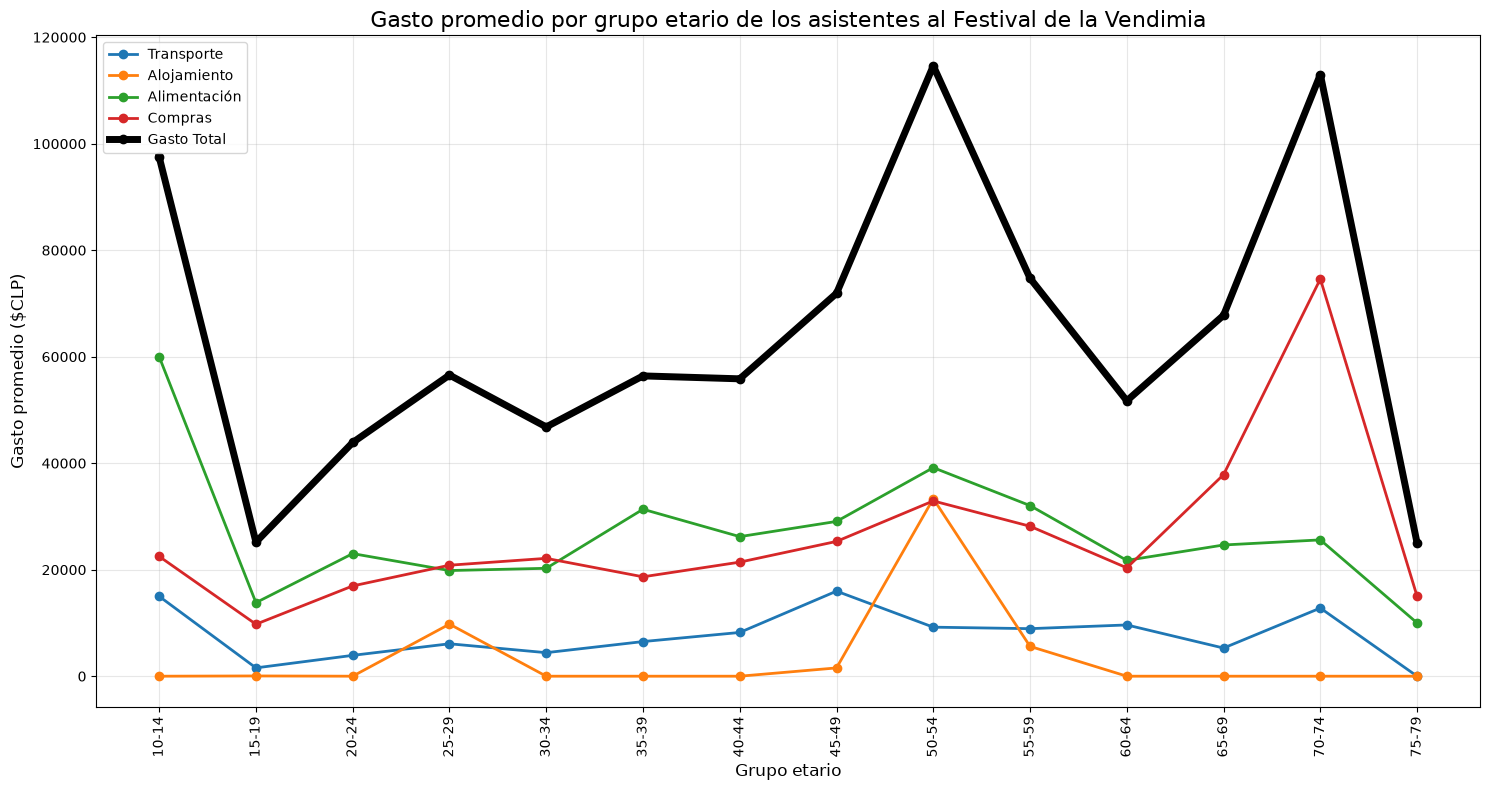

In [114]:
bins = [0, 4, 9, 14, 19, 24, 29, 34, 39, 44, 49,54, 59, 64, 69, 74, 79, 84, 100]
labels = ["0-4", "5-9", "10-14", "15-19","20-24", "25-29", "30-34", "35-39","40-44", "45-49", "50-54", "55-59","60-64", "65-69", "70-74", "75-79","80-84", "85+"]

vendimia["Grupo_Edad"] = pd.cut(vendimia["Edad"],bins=bins,labels=labels,include_lowest=True)

gastos_edad = vendimia.groupby("Grupo_Edad")[["Gasto_Transporte","Gasto_Alojamiento","Gasto_Alimentacion","Gasto_Compras","Gasto_Total"]].mean()
dispersion = vendimia.groupby("Grupo_Edad")["Gasto_Total"].std()

fig, ax = plt.subplots(figsize=(15,8))

# Líneas secundarias
ax.plot(gastos_edad.index,gastos_edad["Gasto_Transporte"],marker="o",linewidth=2,label="Transporte")
ax.plot(gastos_edad.index,gastos_edad["Gasto_Alojamiento"],marker="o",linewidth=2,label="Alojamiento")
ax.plot(gastos_edad.index,gastos_edad["Gasto_Alimentacion"],marker="o",linewidth=2,label="Alimentación")
ax.plot(gastos_edad.index,gastos_edad["Gasto_Compras"],marker="o",linewidth=2,label="Compras")

# Línea principal (más gruesa)
ax.plot(gastos_edad.index,gastos_edad["Gasto_Total"],marker="o",linewidth=5,color="black",label="Gasto Total")

plt.title("Gasto promedio por grupo etario de los asistentes al Festival de la Vendimia",fontsize=16)

plt.xlabel("Grupo etario", fontsize=12)
plt.ylabel("Gasto promedio ($CLP)", fontsize=12)

# Etiquetas verticales
plt.xticks(rotation=90)
plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

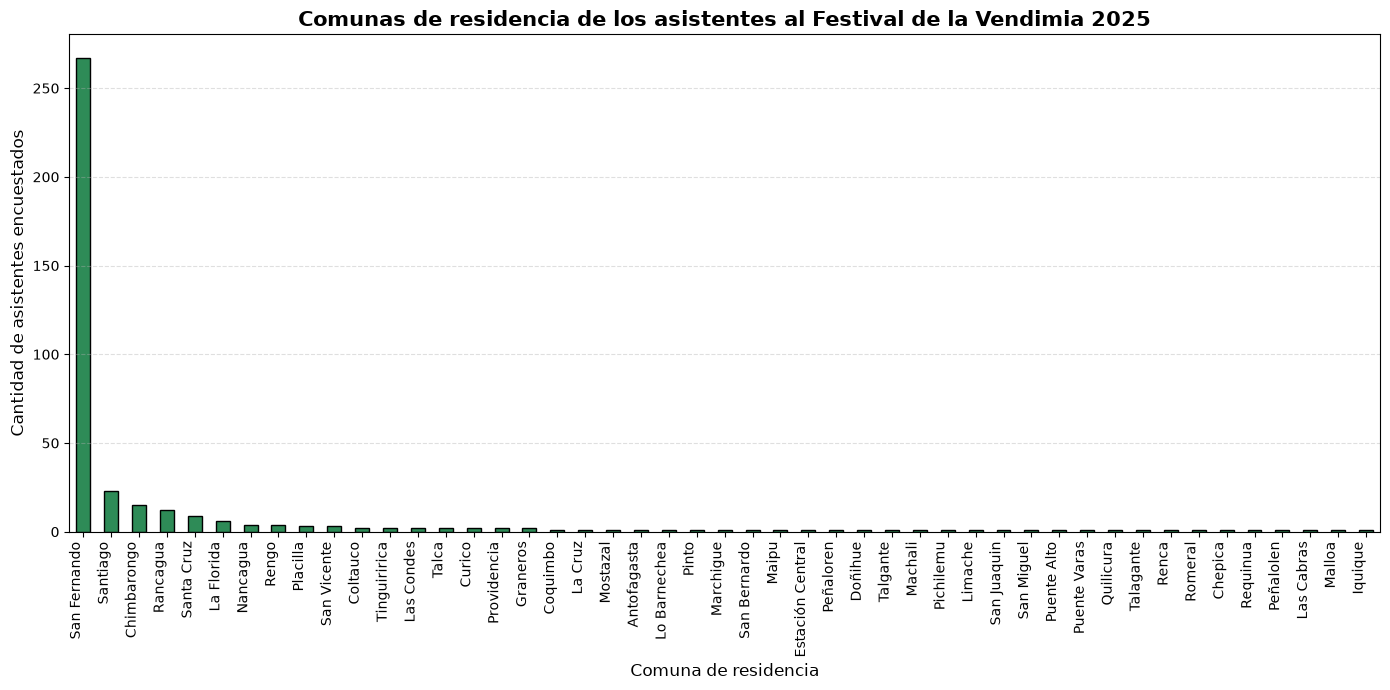

In [120]:
#Segundo gráfico
comunas = (vendimia["Comuna"].value_counts().head(50))

fig, ax = plt.subplots(figsize=(14, 7))
comunas.plot(kind="bar",color="#2E8B57",edgecolor="black",ax=ax)

# Etiquetas sobre las barras


plt.title("Comunas de residencia de los asistentes al Festival de la Vendimia 2025",fontsize=15,weight="bold")

plt.xlabel("Comuna de residencia",fontsize=12)

plt.ylabel("Cantidad de asistentes encuestados",fontsize=12)

plt.xticks(rotation=90,ha="right")
plt.grid(axis="y",linestyle="--",alpha=0.4)

plt.tight_layout()

plt.show()

En este segundo grafico, se observa que las personas que mas fueron a la vendimia fueron de San Fernando, pero tambien hay que pensar que muchas personas no les gusta hacer la encuesta.

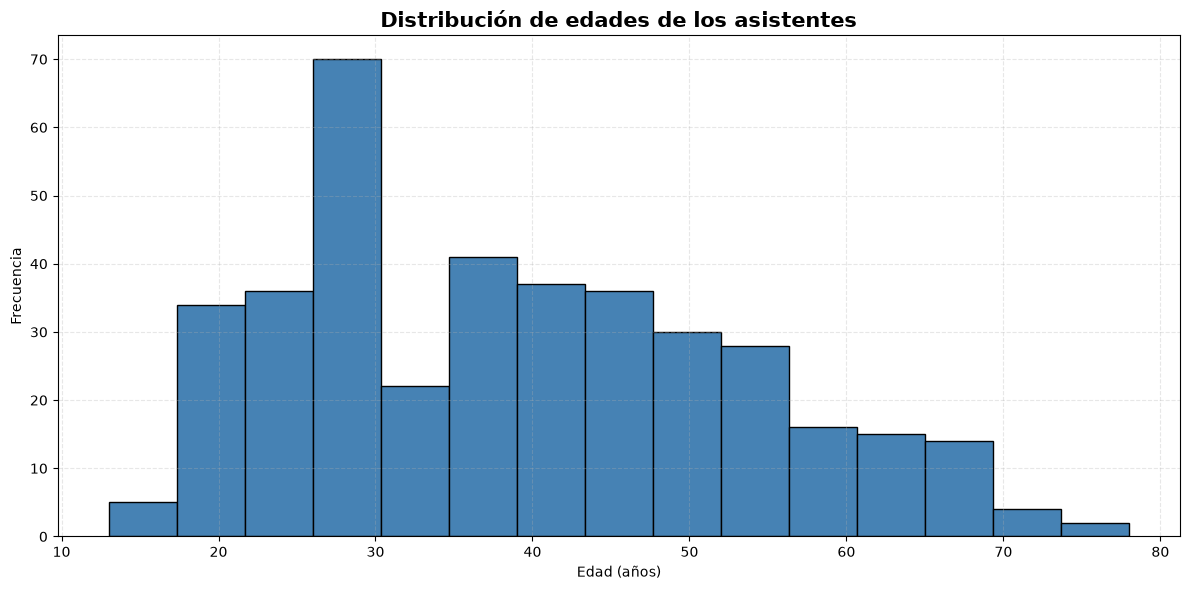

In [ ]:
#Tercer grafico
plt.figure(figsize=(12,6))

plt.hist(vendimia["Edad"],bins=15,color="#4682B4",edgecolor="black")
plt.title("Distribución de edades de los asistentes",fontsize=15,weight="bold")
plt.xlabel("Edad (años)")
plt.ylabel("Frecuencia")

plt.grid(linestyle="--",alpha=0.3)

plt.tight_layout()

plt.show()

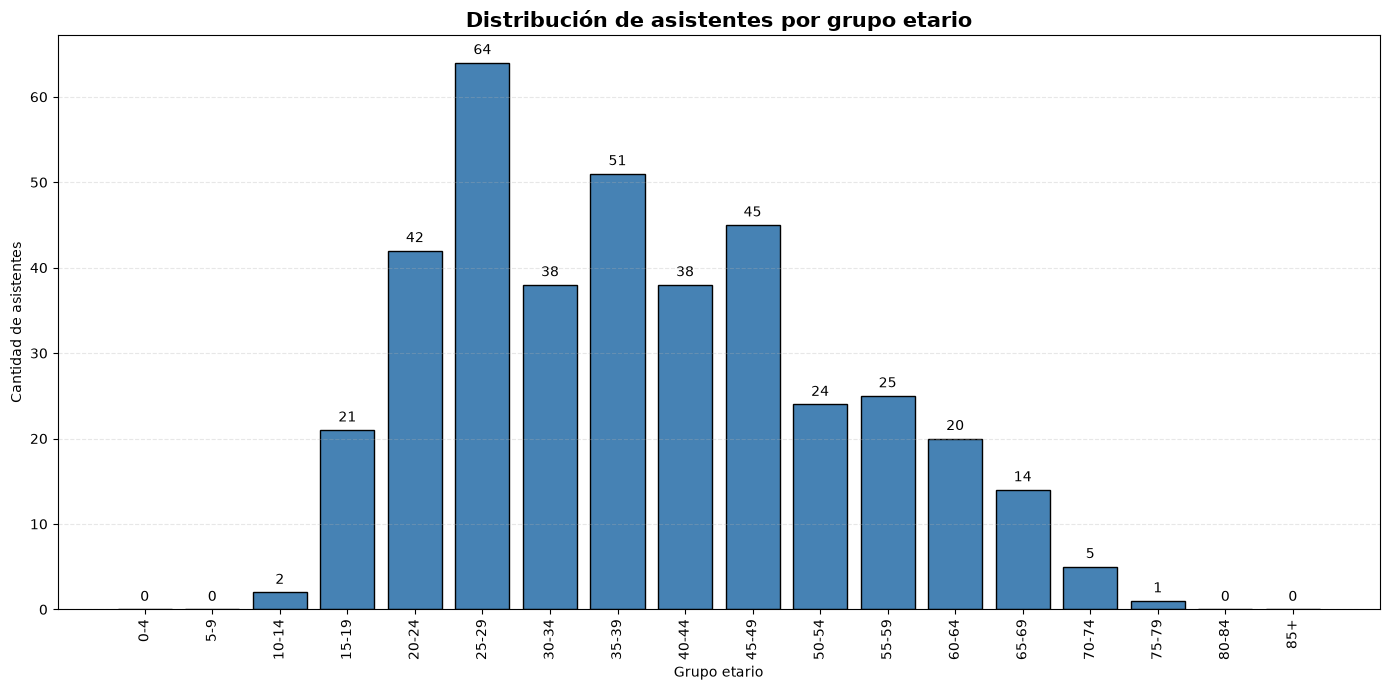

In [122]:
#Tercer grafico en barra 

asistentes_edad = (vendimia["Grupo_Edad"].value_counts().sort_index())
fig, ax = plt.subplots(figsize=(14,7))

bars = ax.bar(asistentes_edad.index,asistentes_edad.values,color="#4682B4",edgecolor="black")

for bar in bars:
    altura = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,altura + 1,f"{int(altura)}",ha="center")

plt.title("Distribución de asistentes por grupo etario",fontsize=15,weight="bold")

plt.xlabel("Grupo etario")
plt.ylabel("Cantidad de asistentes")
plt.xticks(rotation=90)

plt.grid(axis="y",linestyle="--",alpha=0.3)

plt.tight_layout()

plt.show()

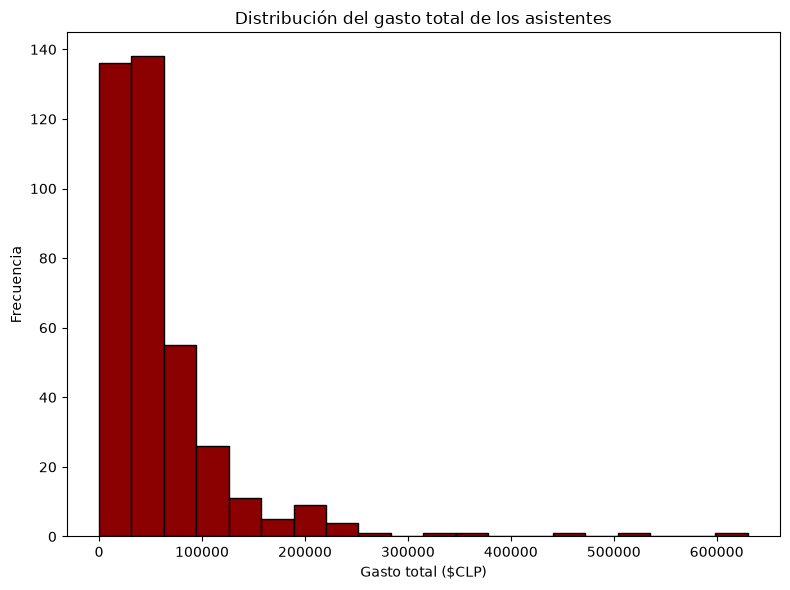

In [ ]:
#Cuarto grafico ver la frecuencia de gastos
plt.figure(figsize=(8,6))

plt.hist(
    vendimia["Gasto_Total"],
    bins=20,
    color="#8B0000",
    edgecolor="black"
)

plt.title(
    "Distribución del gasto total de los asistentes"
)

plt.xlabel("Gasto total ($CLP)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

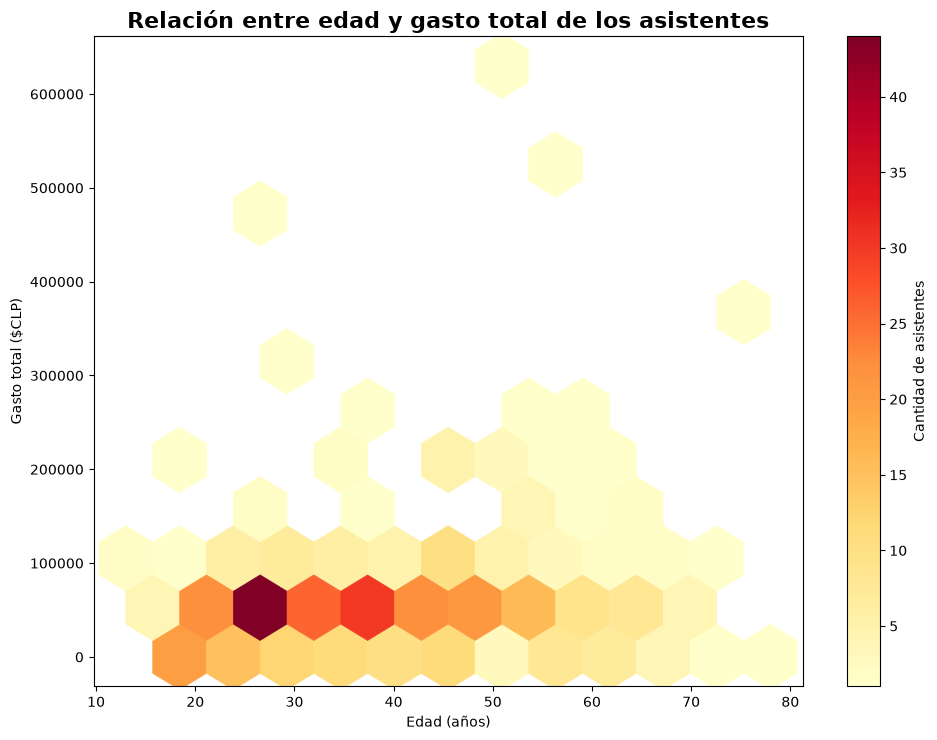

In [ ]:
#Para verlo mejor, se queda se realiza un hexbin y una de tranparencia, pero en relacion con la variable de edad. 
plt.figure(figsize=(10,7.5))

plt.hexbin(
    vendimia["Edad"],
    vendimia["Gasto_Total"],
    gridsize=12,
    cmap="YlOrRd",
    mincnt=1,
    linewidths=0.4
)

cbar = plt.colorbar()
cbar.set_label("Cantidad de asistentes")

plt.title(
    "Relación entre edad y gasto total de los asistentes",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Edad (años)")
plt.ylabel("Gasto total ($CLP)")

plt.tight_layout()
plt.show()

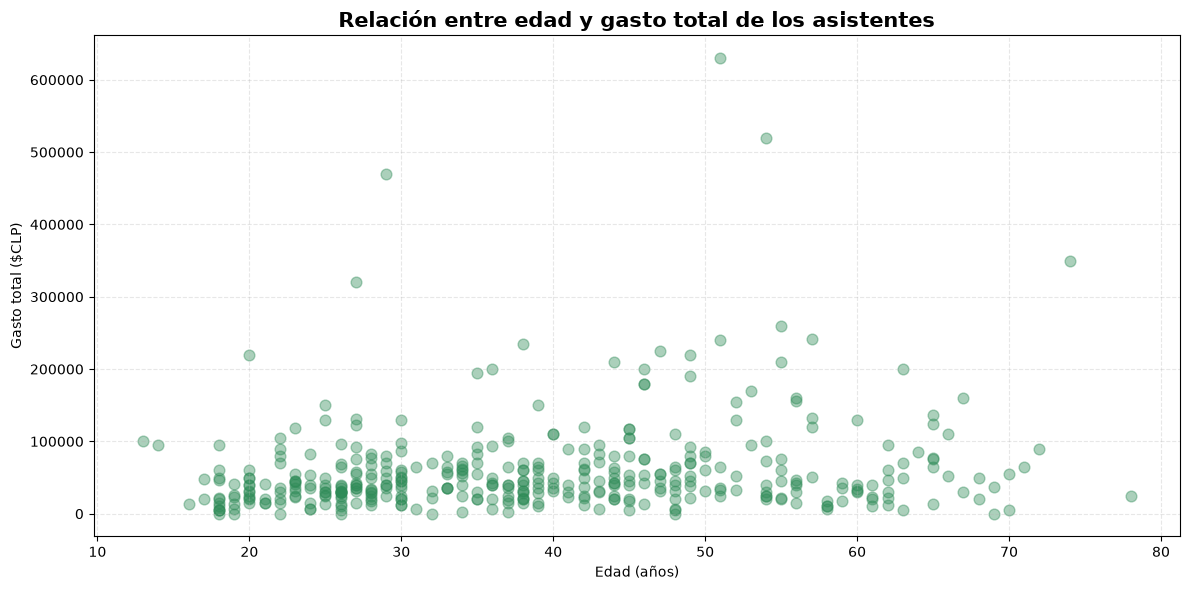

In [130]:
plt.figure(figsize=(12,6))

plt.scatter(
    vendimia["Edad"],
    vendimia["Gasto_Total"],
    alpha=0.4,
    s=60,
    color="#2E8B57"
)

plt.title(
    "Relación entre edad y gasto total de los asistentes",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Edad (años)")
plt.ylabel("Gasto total ($CLP)")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

Hallazgos y siguintes pasos

Los hallazgos de los datos fueron:
1.	La mayoría de los asistentes al Festival de la Vendimia proviene de la comuna de San Fernando, observándose además una participación relevante de visitantes provenientes de Santiago, Chimbarongo y Rancagua. Esto sugiere que el evento posee una fuerte convocatoria local, aunque también logra atraer visitantes desde otras comunas de la Región de O'Higgins y de la Región Metropolitana.
2.	La edad promedio de los asistentes fue de 38,8 años y la mayor concentración de participantes se observó entre los 20 y 45 años. Esto indica que el público del festival está compuesto principalmente por adultos jóvenes y adultos en edad laboral activa.
3.	La mayoría de los asistentes no requirió alojamiento durante su visita al festival. Tanto la mediana como la moda de los días de alojamiento fueron iguales a cero, lo que evidencia una predominancia de visitas por el día y una importante participación de residentes locales.
4.	El gasto total promedio fue cercano a $60.000 por asistente, aunque la mediana fue de aproximadamente $41.000. Esta diferencia refleja la existencia de un grupo reducido de visitantes que realiza gastos considerablemente superiores al promedio, generando una distribución asimétrica del gasto.
5.	Las variables asociadas al gasto presentaron asimetrías positivas elevadas y altos valores de curtosis, evidenciando la presencia de colas largas y valores extremos. Esto indica que existe heterogeneidad en el comportamiento económico de los asistentes y que algunos visitantes generan un impacto económico significativamente mayor que el resto.
Hubieron mas hallazgos, pero estos son los principales hallazgos para el proyecto. 

A partir del análisis realizado, se observa que la asistencia al Festival de la Vendimia presenta características diferenciadas según el lugar de residencia, los patrones de alojamiento y los niveles de gasto de los visitantes. Los resultados obtenidos sugieren la existencia de distintos perfiles de asistentes, desde residentes locales que realizan visitas por el día hasta visitantes provenientes de otras comunas que requieren alojamiento y registran gastos significativamente superiores.

En la siguiente etapa del proyecto se propone desarrollar un modelo de regresión para explicar el gasto total realizado por los asistentes. Como variable objetivo se utilizará el gasto total, mientras que las variables explicativas consideradas inicialmente serán la edad, los días de alojamiento, el tipo de alojamiento utilizado, la comuna de residencia y otras variables asociadas al comportamiento turístico observadas en la encuesta. Este modelo permitirá identificar cuáles son los factores que presentan una mayor influencia sobre el nivel de gasto realizado durante la visita al festival.

Adicionalmente, se evaluará la incorporación de información proveniente de las bases de viajes ocasionales, población y actividad económica turística, con el objetivo de complementar la caracterización de los visitantes y contextualizar el impacto territorial del evento en la comuna de San Fernando.

Considerando que la encuesta corresponde a una muestra de asistentes y no al universo completo de visitantes, también se propone estudiar la construcción de factores de expansión o ponderadores muestrales que permitan aproximar la asistencia total al evento. Esto permitiría extrapolar los resultados obtenidos a una población más amplia y generar estimaciones más robustas sobre el impacto económico y turístico de la Fiesta de la Vendimia.

Finalmente, se contempla evaluar distintos enfoques de modelamiento, incluyendo modelos de regresión lineal y técnicas más flexibles de aprendizaje automático, con el propósito de comparar su capacidad predictiva y determinar cuál representa de mejor manera el comportamiento del gasto de los asistentes.
